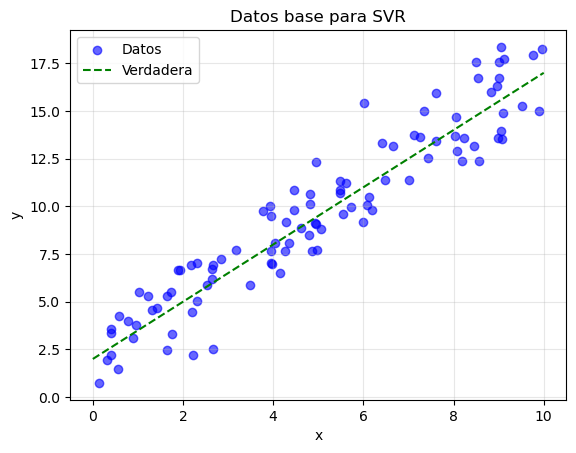

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Datos sintecticos para regrersion (lineal + ruido)
N = 100
x = np.sort(np.random.uniform(0, 10, N))
y = 2.0 + 1.5 * x + np.random.normal(0, 1.5, N)  # ruido moderado

x_test = np.linspace(0, 10, 300)
y_true = 2.0 + 1.5 * x_test

plt.scatter(x, y, color='blue', alpha=0.6, label='Datos')
plt.plot(x_test, y_true, 'g--', label='Verdadera')
plt.title('Datos base para SVR')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
def svr_fit(x, y, C=10, epsilon=0.5):
    """
    SVR lineal desde cero (dual formulation simplificada).
    Tecnologia inversa: maximizamos margen + penalizamos violaciones > ε.
    """
    n = len(x)
    # Matriz del kernel lineal (para SVR lineal)
    K = x[:, None] * x[None, :] # x_i + x_j

    # Funcion objetivo dual (minimizar objetivo)
    def objetive(alpha):
        return 0.5 * alpha @ K @ alpha - np.sum(alpha * y)
    
    # Restricciones
    cons = ({'type': 'eq', 'fun': lambda alpha: np.sum(alpha)},
            {'type': 'ineq', 'fun': lambda alpha: C - alpha},
            {'type': 'ineq', 'fun': lambda alpha: alpha})
    
    # Bounds para alpha
    bounds = [(0, C) for _ in range(n)]

    # Optimizacion (SLSQP para dual)
    from scipy.optimize import minimize
    res = minimize(objetive, np.zeros(n), constraints=cons, bounds=bounds, method='SLSQP')
    alpha = res.x

    # Vector de soporte (alpha > 0)
    sv_idx = alpha > 1e-5
    sv_x = x[sv_idx]
    sv_y = y[sv_idx]
    sv_alpha = alpha[sv_idx]

    # Intercepto (b) promedio de soportes
    b = np.mean(sv_y - sv_alpha @ (sv_x[:, None] * sv_x[None, :]))

    def predict(x_new):
        return b + np.sum(sv_alpha * (sv_x * x_new))
    
    return predict, sv_idx, sv_alpha, sv_x

NameError: name 'sv_y' is not defined

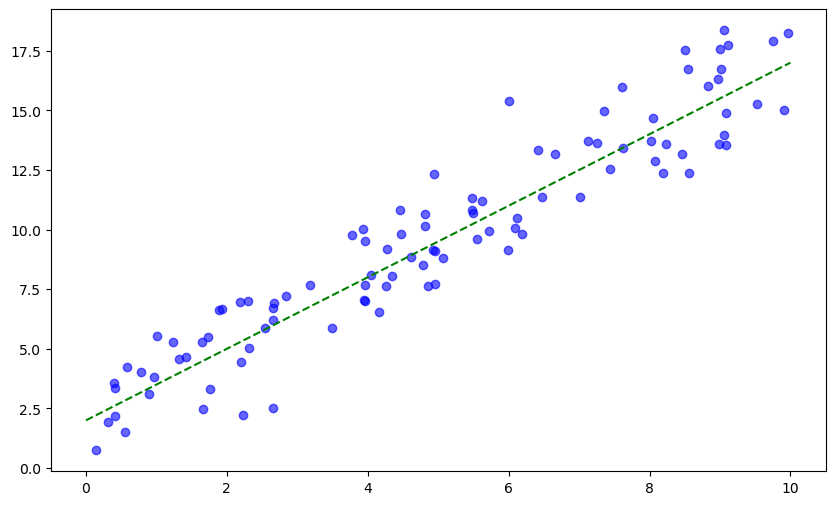

In [6]:
C = 10      # penalización (grande = margen estricto)
epsilon = 0.5  # tubo de insensitividad

predict_svr, sv_idx, sv_alpha, sv_x, = svr_fit(x, y, C=C, epsilon=epsilon)

y_pred_svr = np.array([predict_svr(xi) for xi in x_test])

plt.figure(figsize=(10, 6))
plt.scatter(x, y, color='blue', alpha=0.6, label='Datos')
plt.plot(x_test, y_true, 'g--', label='Verdadera')
plt.plot(x_test, y_pred_svr, 'r-', linewidth=2, label=f'SVR (C={C}, ε={epsilon})')
plt.scatter(sv_x, sv_y[sv_idx], color='red', s=100, edgecolors='black', label=('Support Vestors'))
plt.xlabel('x')
plt.ylabel('y')
plt.title('Support Vector Regression desde cero (Capítulo 9)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()